In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import nltk
import plotly.express as px

In [10]:
df=pd.read_pickle("df_Cleaned_Outliers_Missing.pkl")

with open("spotify_songs_df_text.pkl", "rb") as f:
    df_text = pickle.load(f)

df.head()


,track_id,track_artist,track_popularity,track_album_id,track_album_release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,playlist_count_per_song,duration_minutes,playlist_genre_count_per_song
0,6f807x0ima9a1j3vpbc7vn,ed sheeran,66,2ocs0dgtsro98gh5zsl2cx,2019-06-14,0.748,0.916,6,NaN,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,2,3.25,2
1,0r7cvbztwzgbtcydfa2p31,maroon 5,67,63rpso264urjw1x5e6cwv6,2019-12-13,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,2,2.71,2
2,1z1hg7vb0ahhdiemnde79l,zara larsson,70,1hosmj2elcsrr0ve9gthr4,2019-07-05,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,3,2.94,3
3,75fpbthrwqmzhlbjlugdc7,the chainsmokers,60,1nqysoef1ykkugovchbsk6,2019-07-19,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,1,2.82,1
4,1e8pafckuyokkxphrhqw4x,lewis capaldi,69,7m7vv9wlq4i0lfujie2zsq,2019-03-05,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,1,3.15,1


In [11]:
df.head()

,track_id,track_artist,track_popularity,track_album_id,track_album_release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,playlist_count_per_song,duration_minutes,playlist_genre_count_per_song
0,6f807x0ima9a1j3vpbc7vn,ed sheeran,66,2ocs0dgtsro98gh5zsl2cx,2019-06-14,0.748,0.916,6,NaN,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,2,3.25,2
1,0r7cvbztwzgbtcydfa2p31,maroon 5,67,63rpso264urjw1x5e6cwv6,2019-12-13,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,2,2.71,2
2,1z1hg7vb0ahhdiemnde79l,zara larsson,70,1hosmj2elcsrr0ve9gthr4,2019-07-05,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,3,2.94,3
3,75fpbthrwqmzhlbjlugdc7,the chainsmokers,60,1nqysoef1ykkugovchbsk6,2019-07-19,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,1,2.82,1
4,1e8pafckuyokkxphrhqw4x,lewis capaldi,69,7m7vv9wlq4i0lfujie2zsq,2019-03-05,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,1,3.15,1


In [12]:
df_text.head()

,track_id,track_name,track_album_name,playlist_name
0,6f807x0ima9a1j3vpbc7vn,I Dont Care with Justin Bieber Loud Luxury Remix,I Dont Care with Justin Bieber Loud Luxury Remix,Pop Remix
1,0r7cvbztwzgbtcydfa2p31,Memories Dillon Francis Remix,Memories Dillon Francis Remix,Pop Remix
2,1z1hg7vb0ahhdiemnde79l,All the Time Don Diablo Remix,All the Time Don Diablo Remix,Pop Remix
3,75fpbthrwqmzhlbjlugdc7,Call You Mine Keanu Silva Remix,Call You Mine The Remixes,Pop Remix
4,1e8pafckuyokkxphrhqw4x,Someone You Loved Future Humans Remix,Someone You Loved Future Humans Remix,Pop Remix


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   track_id                       32833 non-null  string        
 1   track_artist                   32828 non-null  string        
 2   track_popularity               32833 non-null  int64         
 3   track_album_id                 32833 non-null  string        
 4   track_album_release_date       30947 non-null  datetime64[ns]
 5   danceability                   27371 non-null  float64       
 6   energy                         28675 non-null  float64       
 7   key                            32833 non-null  int64         
 8   loudness                       27030 non-null  float64       
 9   mode                           32833 non-null  int64         
 10  speechiness                    26790 non-null  float64       
 11  acousticness   

In [14]:
df_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   track_id          32833 non-null  string
 1   track_name        32828 non-null  string
 2   track_album_name  32828 non-null  string
 3   playlist_name     32833 non-null  string
dtypes: string(4)
memory usage: 1.0 MB


In [15]:
### Extract year and month, converting them explicitly to integers

In [85]:
df['track_album_release_year'] = df['track_album_release_date'].dt.year.astype('Int64')
df['track_album_release_month'] = df['track_album_release_date'].dt.month.astype('Int64')

# Drop the original column if it's no longer needed
df.drop(columns=['track_album_release_date'], inplace=True)

# Display the updated DataFrame
print(df[['track_album_release_year', 'track_album_release_month']].head())

   track_album_release_year  track_album_release_month
0                      2019                          6
1                      2019                         12
2                      2019                          7
3                      2019                          7
4                      2019                          3


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       32833 non-null  string 
 1   track_artist                   32828 non-null  string 
 2   track_popularity               32833 non-null  int64  
 3   track_album_id                 32833 non-null  string 
 4   danceability                   27371 non-null  float64
 5   energy                         28675 non-null  float64
 6   key                            32833 non-null  int64  
 7   loudness                       27030 non-null  float64
 8   mode                           32833 non-null  int64  
 9   speechiness                    26790 non-null  float64
 10  acousticness                   27357 non-null  float64
 11  instrumentalness               32833 non-null  float64
 12  liveness                       32833 non-null 

# New columns from track_name

In [17]:
import pandas as pd
from langdetect import detect, DetectorFactory
from concurrent.futures import ThreadPoolExecutor

# Ensure consistent results
DetectorFactory.seed = 0  

# Function to detect language
def detect_language(text):
    try:
        return detect(text) if isinstance(text, str) and text.strip() else "unknown"
    except:
        return "unknown"

# Load dataset
df_text = pd.read_pickle("spotify_songs_df_text.pkl")

# Process only unique track names to avoid redundant work
unique_track_names = df_text['track_name'].dropna().unique()

# Use ThreadPoolExecutor (better for I/O tasks like `langdetect`)
track_name_dict = {}
with ThreadPoolExecutor() as executor:
    results = list(executor.map(detect_language, unique_track_names))

In [100]:
# Map results back to original DataFrame
track_name_dict = dict(zip(unique_track_names, results))
df_text['language'] = df_text['track_name'].map(track_name_dict)


In [23]:
# Display results
language_counts = (df_text['language'].value_counts())
print(language_counts)

language
en         16410
de          2833
es          1410
af          1003
ca           976
it           976
pt           885
id           801
fr           798
tl           704
nl           687
da           573
cy           518
ro           429
sw           402
so           397
fi           395
no           387
et           312
pl           302
unknown      262
tr           204
sv           201
sl           174
hr           165
lt           142
vi           111
cs           108
hu            83
sq            80
sk            72
lv            28
Name: count, dtype: int64


C:\Users\Meital atar\AppData\Local\Temp\ipykernel_13372\2914249310.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




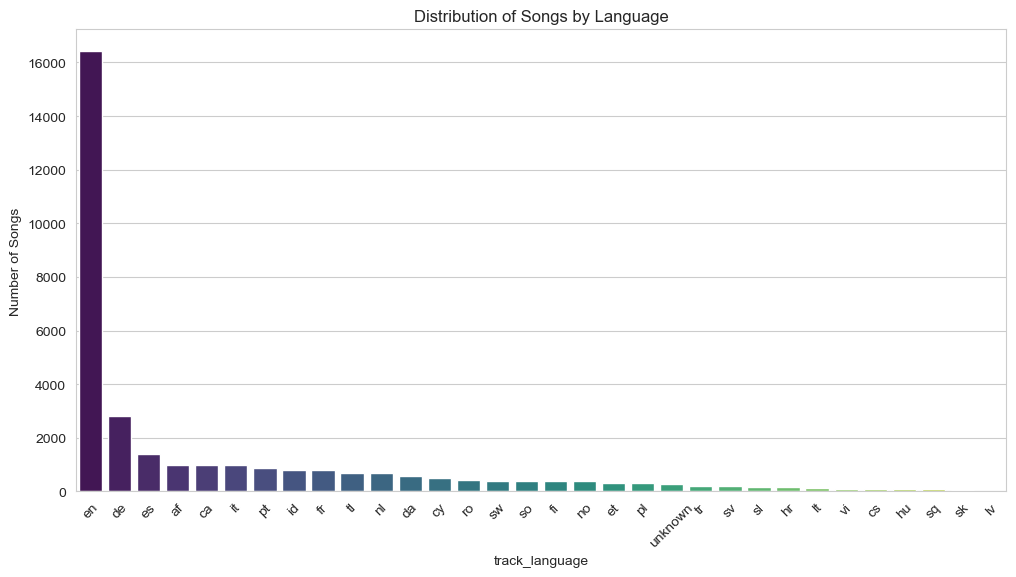

In [104]:
# Plot the results
plt.figure(figsize=(12, 6))
sns.barplot(x=language_counts.index, y=language_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("track_language")
plt.ylabel("Number of Songs")
plt.title("Distribution of Songs by Language")
plt.xticks(rotation=45)  # Rotate labels for readability
plt.show()

In [109]:
import pandas as pd

# Ensure 'language' column exists and clean it
df_text["language"] = df_text["language"].astype(str).str.strip().str.lower().fillna("unknown")

# Categorize as English or Not English
df["language_category"] = df_text["language"].apply(lambda x: "English" if x == "en" else "Not English")

# Display counts
print(df["language_category"].value_counts())

# Verify original language distribution
print(df_text["language"].value_counts())


language_category
Not English    32620
English          213
Name: count, dtype: int64
language
nan        31661
unknown      252
en           213
it            74
id            57
fi            46
sw            36
af            35
fr            34
da            33
cy            32
de            32
tl            31
so            31
no            27
es            27
sv            26
et            22
nl            19
hr            18
tr            17
pt            17
ca            15
sq            15
ro            13
sk            12
sl             9
lt             7
pl             7
hu             5
vi             4
cs             3
lv             3
Name: count, dtype: int64


In [90]:
df.info() # checking 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       32833 non-null  string 
 1   track_artist                   32828 non-null  string 
 2   track_popularity               32833 non-null  int64  
 3   track_album_id                 32833 non-null  string 
 4   danceability                   27371 non-null  float64
 5   energy                         28675 non-null  float64
 6   key                            32833 non-null  int64  
 7   loudness                       27030 non-null  float64
 8   mode                           32833 non-null  int64  
 9   speechiness                    26790 non-null  float64
 10  acousticness                   27357 non-null  float64
 11  instrumentalness               32833 non-null  float64
 12  liveness                       32833 non-null 

In [28]:
# artist_type

In [32]:
import pandas as pd
import re
import nltk
from nltk.corpus import names

# Download NLTK name corpus if not available
nltk.download('names')

# Load male and female names from NLTK corpus
male_names = set(names.words('male.txt'))
female_names = set(names.words('female.txt'))

# Keywords indicating a band
band_keywords = ["band", "orchestra", "quartet", "group", "ensemble", "choir", "collective", "crew"]

# Function to classify artist type
def classify_artist(artist_name):
    if not isinstance(artist_name, str) or not artist_name.strip():
        return "Unknown"  # Handle empty or NaN values
    
    artist_name_lower = artist_name.lower()

    # Check if the artist is a band
    if any(keyword in artist_name_lower for keyword in band_keywords) or "&" in artist_name or " and " in artist_name_lower:
        return "Band"

    # Extract the first word as the assumed first name
    first_name = artist_name.split()[0].capitalize()

    # Classify as Female if the first name matches female names
    if first_name in female_names:
        return "Female"

    # Classify as Male if the first name matches male names
    if first_name in male_names:
        return "Male"

    # Default to Male if unknown (assumption: more male artists exist in the dataset)
    return "Male"


# Apply classification
df['track_artist_type'] = df['track_artist'].apply(classify_artist)

# Display results
print(df)



      track_artist track_artist_type
0            Adele            Female
1      The Beatles              Male
2       John Mayer              Male
3                            Unknown
4          Beyoncé              Male
5             None           Unknown
6            Queen              Male
7  Orchestra Magic              Band


[nltk_data] Downloading package names to C:\Users\Meital
[nltk_data]     atar\AppData\Roaming\nltk_data...
[nltk_data]   Package names is already up-to-date!


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       32833 non-null  string 
 1   track_artist                   32828 non-null  string 
 2   track_popularity               32833 non-null  int64  
 3   track_album_id                 32833 non-null  string 
 4   danceability                   27371 non-null  float64
 5   energy                         28675 non-null  float64
 6   key                            32833 non-null  int64  
 7   loudness                       27030 non-null  float64
 8   mode                           32833 non-null  int64  
 9   speechiness                    26790 non-null  float64
 10  acousticness                   27357 non-null  float64
 11  instrumentalness               32833 non-null  float64
 12  liveness                       32833 non-null 

In [43]:
# Load datasets
tracks_df = pd.read_csv(r"C:\Users\Meital atar\Documents\DATA_SCIENCE\ML_PROJECT_spotify_songs\Kaggel_files\tracks.csv")

# Ensure 'track_id' and 'id' columns exist
if 'track_id' in df.columns and 'id' in tracks_df.columns:
    # Merge on 'track_id' and keep the 'explicit' column
    df_merge = df.merge(tracks_df[['id', 'explicit']], left_on='track_id', right_on='id', how='left')

    # Display result
    print(df_merge.head())
else:
    print("Columns 'track_id' or 'id' are missing!")

Columns 'track_id' or 'id' are missing!


In [49]:
import pandas as pd
from deep_translator import GoogleTranslator

In [50]:
# Function to clean text (assuming clean_text is defined elsewhere)
def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return []  # Return an empty list for missing or invalid values
    words = text.lower().split()  
    return words

# Load dataset
df_text = pd.read_pickle("spotify_songs_df_text.pkl")

# Apply text cleaning
df_text["cleaned_words"] = df_text["track_name"].astype(str).map(clean_text)

# Prepare data for batch translation
unique_texts = df_text["cleaned_words"].apply(lambda words: " ".join(words)).unique()

# Translate only unique texts in bulk
translator = GoogleTranslator(source="auto", target="en")
translation_dict = {text: translator.translate(text) for text in unique_texts if text.strip()}

# Apply translations to the DataFrame
df_text["track_name_english"] = df_text["cleaned_words"].apply(lambda words: translation_dict.get(" ".join(words), ""))



In [ ]:
# Word frequency analysis

In [54]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import plotly.express as px

# Ensure stopwords are downloaded
nltk.download("stopwords")

# Get all available stopwords from NLTK
available_languages = stopwords.fileids()

[nltk_data] Downloading package stopwords to C:\Users\Meital
[nltk_data]     atar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[nltk_data] Downloading package stopwords to C:\Users\Meital
[nltk_data]     atar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 5 most popular words in track names:
       Word  Track_Count
24    love         1264
211   back          276
296  night          274
104   life          266
990   live          242


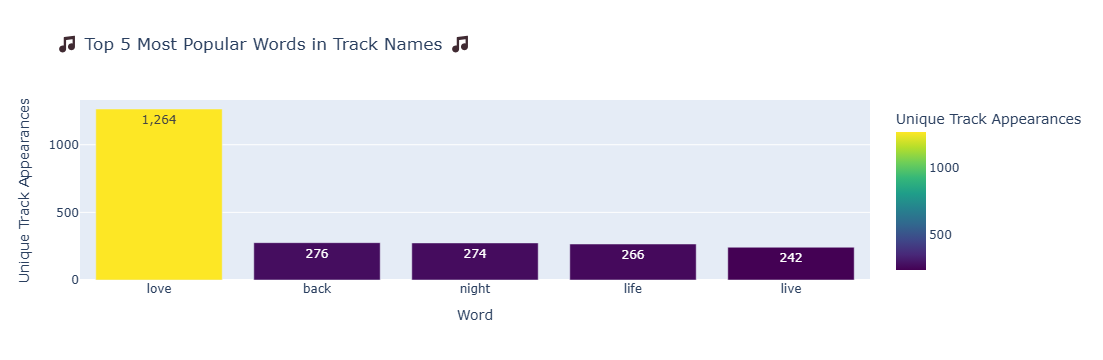


🎵 Example songs for 'love':
- tough love tisto remix radio edit
- love me less feat quinn xcii party pupils remix
- higher love
- need your love with noah kahan
- first love

🎵 Example songs for 'back':
- body back feat maia wright
- all comes back to you
- never go back robin schulz remix
- way back home
- back forth

🎵 Example songs for 'night':
- stay the night featuring hayley williams of paramore
- all day and night
- night ship
- marudesaturday night
- middle of the night

🎵 Example songs for 'life':
- ruin my life steve james remix
- ruin my life
- ritmo bad boys for life
- one life
- daydreams sultan shepard echoes of life remix

🎵 Example songs for 'live':
- open over us live
- live forever with cheat codes
- if you cant live without me why arent you dead yet
- live while were young
- Long live life


In [73]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import plotly.express as px

# Ensure stopwords are downloaded
nltk.download("stopwords")

# Get all available stopwords from NLTK
available_languages = stopwords.fileids()

# Collect stopwords for multiple languages
multi_language_stopwords = set()
for lang in available_languages:
    multi_language_stopwords.update(stopwords.words(lang))

# Add custom stopwords (common track name words)
custom_stopwords = {
    "remix", "mix", "version", "edit", "feat", "radio", 
    "extended", "the", "and", "original", "remastered", "remaster"
}

# Combine all stopwords
stop_words = multi_language_stopwords | custom_stopwords

# Tokenize and remove stopwords safely
df_text["filtered_words"] = (
    df_text["track_name_english"]
    .fillna("")  # Handle NaN values
    .str.lower()
    .str.split()
    .apply(lambda words: list(set(word for word in words if word not in stop_words)))  # Remove duplicates per track
)

# Flatten word lists and count how many UNIQUE tracks contain each word
all_words = [word for word_list in df_text["filtered_words"] for word in word_list]
word_counts = Counter(all_words)

# Convert to DataFrame
word_popularity_df = pd.DataFrame(word_counts.items(), columns=["Word", "Track_Count"])

# Sort by most common words in unique track names
word_popularity_df = word_popularity_df.sort_values(by="Track_Count", ascending=False)

# Take the **top 5 most popular words**
top_5_words = word_popularity_df.head(5)
print("Top 5 most popular words in track names:\n", top_5_words)


# Create an interactive bar chart using Plotly
fig = px.bar(
    top_5_words,
    x="Word",
    y="Track_Count",
    title="🎵 Top 5 Most Popular Words in Track Names 🎵",
    text=top_5_words["Track_Count"].apply(lambda x: f"{x:,}"),  # Format numbers with commas
    labels={"Word": "Word", "Track_Count": "Unique Track Appearances"},
    color="Track_Count",
    color_continuous_scale=px.colors.sequential.Viridis,  # Modern color gradient
)

# Show chart
fig.show()

# Find 5 example songs for each word
example_songs = {}
for word in top_5_words["Word"]:
    example_songs[word] = df_text[df_text["track_name_english"].str.contains(fr"\b{word}\b", case=False, regex=True)]["track_name_english"].head(5).tolist()

# Print the example songs
for word, songs in example_songs.items():
    print(f"\n🎵 Example songs for '{word}':")
    for song in songs:
        print(f"- {song}")





In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   track_artist       7 non-null      object
 1   track_artist_type  8 non-null      object
 2   word_1             8 non-null      object
 3   word_2             8 non-null      object
 4   word_3             8 non-null      object
 5   word_4             8 non-null      object
 6   word_1             8 non-null      object
 7   word_2             8 non-null      object
 8   word_3             8 non-null      object
 9   word_4             8 non-null      object
dtypes: object(10)
memory usage: 772.0+ bytes


In [81]:
df.to_csv('df_after_feature_eng.csv')
df.to_pickle ('df_after_feature_eng.pkl')

In [84]:
df=pd.read_pickle("df_Cleaned_Outliers_Missing.pkl")
df

,track_id,track_artist,track_popularity,track_album_id,track_album_release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,playlist_count_per_song,duration_minutes,playlist_genre_count_per_song
0,6f807x0ima9a1j3vpbc7vn,ed sheeran,66,2ocs0dgtsro98gh5zsl2cx,2019-06-14,0.748,0.916,6,NaN,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,2,3.25,2
1,0r7cvbztwzgbtcydfa2p31,maroon 5,67,63rpso264urjw1x5e6cwv6,2019-12-13,0.726,0.815,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,2,2.71,2
2,1z1hg7vb0ahhdiemnde79l,zara larsson,70,1hosmj2elcsrr0ve9gthr4,2019-07-05,0.675,0.931,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,3,2.94,3
3,75fpbthrwqmzhlbjlugdc7,the chainsmokers,60,1nqysoef1ykkugovchbsk6,2019-07-19,0.718,0.930,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,1,2.82,1
4,1e8pafckuyokkxphrhqw4x,lewis capaldi,69,7m7vv9wlq4i0lfujie2zsq,2019-03-05,0.650,0.833,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,1,3.15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnkaamr3snq1vgluvfc1,lush simon,42,2azrobbweeeyhqv6sb7jrt,2014-04-28,NaN,0.922,2,NaN,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,1,3.41,1
32829,5aevni09em4575077nkwhz,tegan and sara,20,6kd6klxj7s8ece3abvayf5,2013-03-08,0.522,0.786,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,1,5.89,1
32830,7immqpp3q1yfuhvsdn7weo,starkillers,14,0ltwnsy9jgxoizo4vzuca6,2014-04-21,0.529,0.821,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,1,3.50,1
32831,2m69mhnfq1oq6lgtxuyhgx,mat zo,15,1fgrokhnhjcstl14znx8jy,2014-01-01,0.626,0.888,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,1,6.12,1


In [111]:
df.to_csv('df_after_feature_eng.csv')
df.to_pickle ('df_after_feature_eng.pkl')